In [56]:
!pip install torch torchvision
!pip install pydicom
!pip install opencv-python
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn
!pip install grad-cam
!pip install streamlit

In [57]:
!pip install -U kagglehub
import kagglehub

kagglehub.login()

In [58]:
path = kagglehub.competition_download(
    'rsna-pneumonia-detection-challenge'
)

print("Dataset path:")
print(path)


Dataset path:
/root/.cache/kagglehub/competitions/rsna-pneumonia-detection-challenge


In [59]:
import os

path = "/root/.cache/kagglehub/competitions/rsna-pneumonia-detection-challenge"

for item in os.listdir(path):
    print(item)

stage_2_detailed_class_info.csv
stage_2_train_images
GCP Credits Request Link - RSNA.txt
stage_2_test_images
stage_2_train_labels.csv
stage_2_sample_submission.csv


In [60]:
import pandas as pd
import os

path = "/root/.cache/kagglehub/competitions/rsna-pneumonia-detection-challenge"

labels = pd.read_csv(
    os.path.join(path, "stage_2_train_labels.csv")
)

print(labels.head())

                              patientId      x      y  width  height  Target
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6    NaN    NaN    NaN     NaN       0
1  00313ee0-9eaa-42f4-b0ab-c148ed3241cd    NaN    NaN    NaN     NaN       0
2  00322d4d-1c29-4943-afc9-b6754be640eb    NaN    NaN    NaN     NaN       0
3  003d8fa0-6bf1-40ed-b54c-ac657f8495c5    NaN    NaN    NaN     NaN       0
4  00436515-870c-4b36-a041-de91049b9ab4  264.0  152.0  213.0   379.0       1


In [61]:
print(labels["Target"].value_counts())

Target
0    20672
1     9555
Name: count, dtype: int64


In [62]:
print(labels["Target"].value_counts(normalize=True) * 100)

Target
0    68.389188
1    31.610812
Name: proportion, dtype: float64


In [63]:
print(labels.isnull().sum())

patientId        0
x            20672
y            20672
width        20672
height       20672
Target           0
dtype: int64


In [64]:
!pip install -q pydicom

In [65]:
import pydicom
import matplotlib.pyplot as plt
import os

In [66]:
pneumonia = labels[labels["Target"] == 1].iloc[0]

print(pneumonia)

patientId    00436515-870c-4b36-a041-de91049b9ab4
x                                           264.0
y                                           152.0
width                                       213.0
height                                      379.0
Target                                          1
Name: 4, dtype: object


In [67]:
patient_id = pneumonia["patientId"]

image_path = os.path.join(
    path,
    "stage_2_train_images",
    patient_id + ".dcm"
)

print(image_path)
print(os.path.exists(image_path))

/root/.cache/kagglehub/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images/00436515-870c-4b36-a041-de91049b9ab4.dcm
True


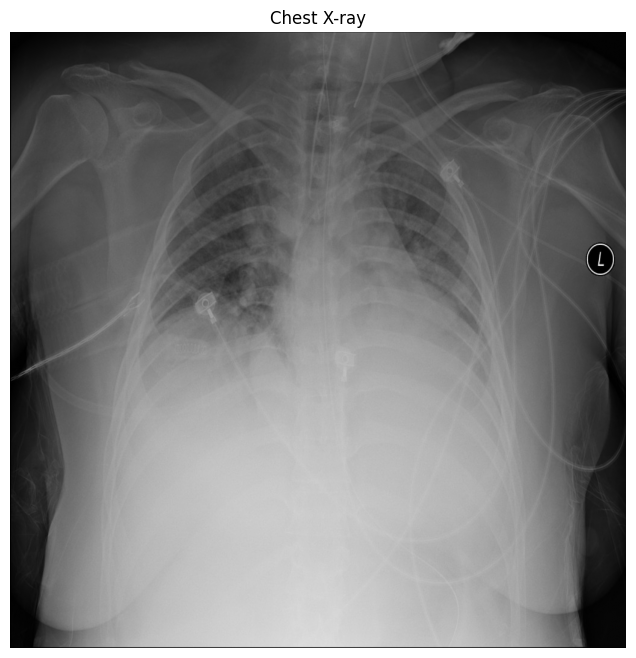

In [68]:
ds = pydicom.dcmread(image_path)

image = ds.pixel_array

plt.figure(figsize=(8, 8))
plt.imshow(image, cmap="gray")
plt.axis("off")
plt.title("Chest X-ray")
plt.show()

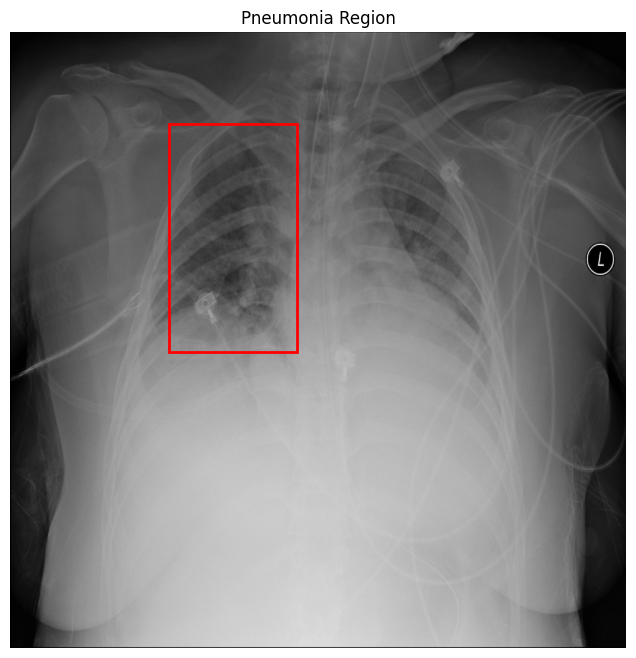

In [69]:
import matplotlib.patches as patches

x = pneumonia["x"]
y = pneumonia["y"]
width = pneumonia["width"]
height = pneumonia["height"]

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(image, cmap="gray")

rect = patches.Rectangle(
    (x, y),
    width,
    height,
    linewidth=2,
    edgecolor="red",
    facecolor="none"
)

ax.add_patch(rect)

ax.set_title("Pneumonia Region")
ax.axis("off")

plt.show()

In [70]:
import pandas as pd
import os

data = labels.groupby("patientId").first().reset_index()

print("Total images:", len(data))
print(data["Target"].value_counts())

Total images: 26684
Target
0    20672
1     6012
Name: count, dtype: int64


In [71]:
data["image_path"] = data["patientId"].apply(
    lambda x: os.path.join(
        path,
        "stage_2_train_images",
        x + ".dcm"
    )
)

print(data[["patientId", "Target", "image_path"]].head())

                              patientId  Target  \
0  0004cfab-14fd-4e49-80ba-63a80b6bddd6       0   
1  000924cf-0f8d-42bd-9158-1af53881a557       0   
2  000db696-cf54-4385-b10b-6b16fbb3f985       1   
3  000fe35a-2649-43d4-b027-e67796d412e0       1   
4  001031d9-f904-4a23-b3e5-2c088acd19c6       1   

                                          image_path  
0  /root/.cache/kagglehub/competitions/rsna-pneum...  
1  /root/.cache/kagglehub/competitions/rsna-pneum...  
2  /root/.cache/kagglehub/competitions/rsna-pneum...  
3  /root/.cache/kagglehub/competitions/rsna-pneum...  
4  /root/.cache/kagglehub/competitions/rsna-pneum...  


In [72]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(
    data,
    test_size=0.30,
    stratify=data["Target"],
    random_state=42
)

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.50,
    stratify=temp_data["Target"],
    random_state=42
)

print("Training:", len(train_data))
print("Validation:", len(val_data))
print("Testing:", len(test_data))

Training: 18678
Validation: 4003
Testing: 4003


In [73]:
train_small = train_data.sample(
    n=min(3000, len(train_data)),
    random_state=42
)

val_small = val_data.sample(
    n=min(500, len(val_data)),
    random_state=42
)

test_small = test_data.sample(
    n=min(500, len(test_data)),
    random_state=42
)

print("Small training set:", len(train_small))
print("Small validation set:", len(val_small))
print("Small test set:", len(test_small))

Small training set: 3000
Small validation set: 500
Small test set: 500


In [74]:
!pip install -q torch torchvision

In [75]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import pydicom
from PIL import Image
import numpy as np

In [76]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [77]:
class PneumoniaDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Read DICOM image
        dicom = pydicom.dcmread(row["image_path"])
        image = dicom.pixel_array.astype(np.float32)

        # Normalize pixel values to 0-255
        image = image - image.min()

        if image.max() > 0:
            image = image / image.max()

        image = (image * 255).astype(np.uint8)

        # Convert grayscale → RGB
        image = Image.fromarray(image).convert("RGB")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Label
        label = torch.tensor(
            row["Target"],
            dtype=torch.float32
        )

        return image, label

In [78]:
train_dataset = PneumoniaDataset(
    train_small,
    transform=transform
)

val_dataset = PneumoniaDataset(
    val_small,
    transform=transform
)

test_dataset = PneumoniaDataset(
    test_small,
    transform=transform
)

In [79]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

In [80]:
images, labels_batch = next(iter(train_loader))

print("Image shape:", images.shape)
print("Labels shape:", labels_batch.shape)
print("Labels:", labels_batch)

Image shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])
Labels: tensor([0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.])


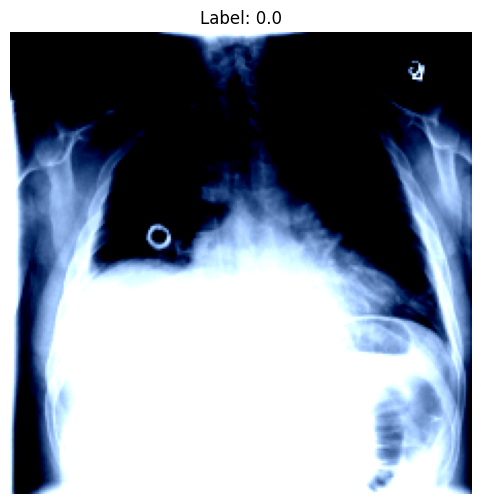

In [81]:
import matplotlib.pyplot as plt

image = images[0].permute(1, 2, 0).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title(f"Label: {labels_batch[0].item()}")
plt.show()

In [82]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [83]:
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# Replace the final layer: 1024 features -> 1 output (pneumonia or not)
model.classifier = nn.Linear(model.classifier.in_features, 1)

model = model.to(device)

In [84]:
num_neg = (train_small["Target"] == 0).sum()
num_pos = (train_small["Target"] == 1).sum()

pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)
print("pos_weight:", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

pos_weight: 3.444444417953491


In [85]:
from sklearn.metrics import roc_auc_score

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader):
    model.eval()
    total_loss = 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)

            all_probs.extend(torch.sigmoid(outputs).cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / len(loader.dataset), auc

In [86]:
import time

best_auc = 0
EPOCHS = 5

for epoch in range(EPOCHS):
    start = time.time()
    train_loss = train_one_epoch(model, train_loader)
    val_loss, val_auc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train loss: {train_loss:.4f} | "
          f"Val loss: {val_loss:.4f} | "
          f"Val AUC: {val_auc:.4f} | "
          f"{time.time()-start:.0f}s")

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), "best_densenet121.pth")
        print("  -> saved best model")

Epoch 1/5 | Train loss: 0.8259 | Val loss: 0.7935 | Val AUC: 0.8436 | 97s
  -> saved best model
Epoch 2/5 | Train loss: 0.6425 | Val loss: 0.7934 | Val AUC: 0.8447 | 68s
  -> saved best model
Epoch 3/5 | Train loss: 0.4647 | Val loss: 1.1429 | Val AUC: 0.8285 | 71s
Epoch 4/5 | Train loss: 0.2976 | Val loss: 1.4606 | Val AUC: 0.8263 | 66s
Epoch 5/5 | Train loss: 0.2042 | Val loss: 1.3783 | Val AUC: 0.7991 | 69s


Test AUC: 0.8519
Confusion matrix:
  TN=275  FP=119
  FN=19  TP=87
Sensitivity (pneumonia caught): 0.821
Specificity (normal cleared):   0.698
Accuracy:                       0.724
              precision    recall  f1-score   support

      Normal       0.94      0.70      0.80       394
   Pneumonia       0.42      0.82      0.56       106

    accuracy                           0.72       500
   macro avg       0.68      0.76      0.68       500
weighted avg       0.83      0.72      0.75       500



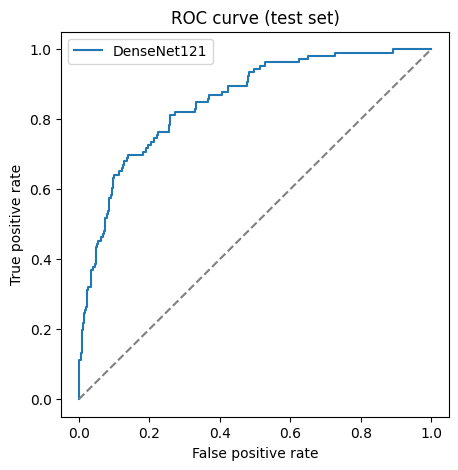

In [87]:
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
import matplotlib.pyplot as plt
import numpy as np

# Load the best model saved during training
model.load_state_dict(torch.load("best_densenet121.pth", map_location=device))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        all_probs.extend(torch.sigmoid(outputs).cpu().numpy().flatten())
        all_labels.extend(labels.numpy().flatten())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Overall ranking quality
print("Test AUC:", round(roc_auc_score(all_labels, all_probs), 4))

# Hard predictions at a 0.5 threshold
preds = (all_probs >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

print("Confusion matrix:")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")
print(f"Sensitivity (pneumonia caught): {tp/(tp+fn):.3f}")
print(f"Specificity (normal cleared):   {tn/(tn+fp):.3f}")
print(f"Accuracy:                       {(tp+tn)/len(preds):.3f}")

print(classification_report(all_labels, preds,
                            target_names=["Normal", "Pneumonia"]))

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label="DenseNet121")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (test set)")
plt.legend()
plt.show()

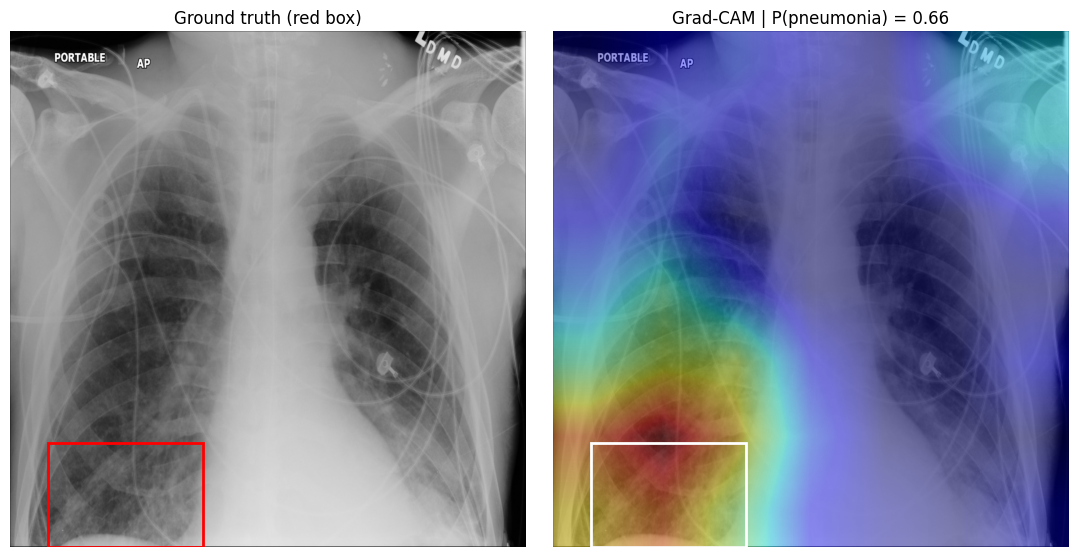

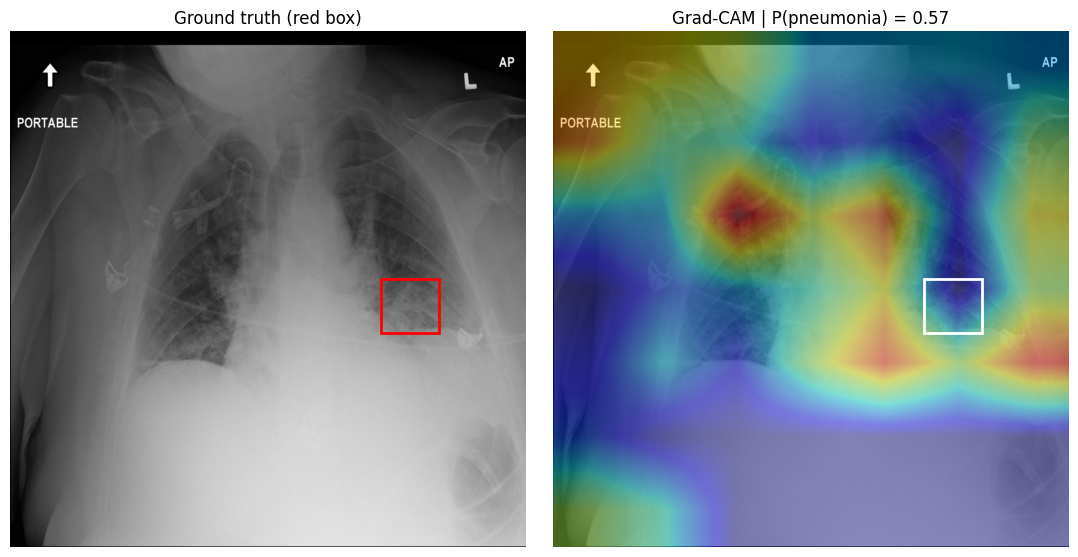

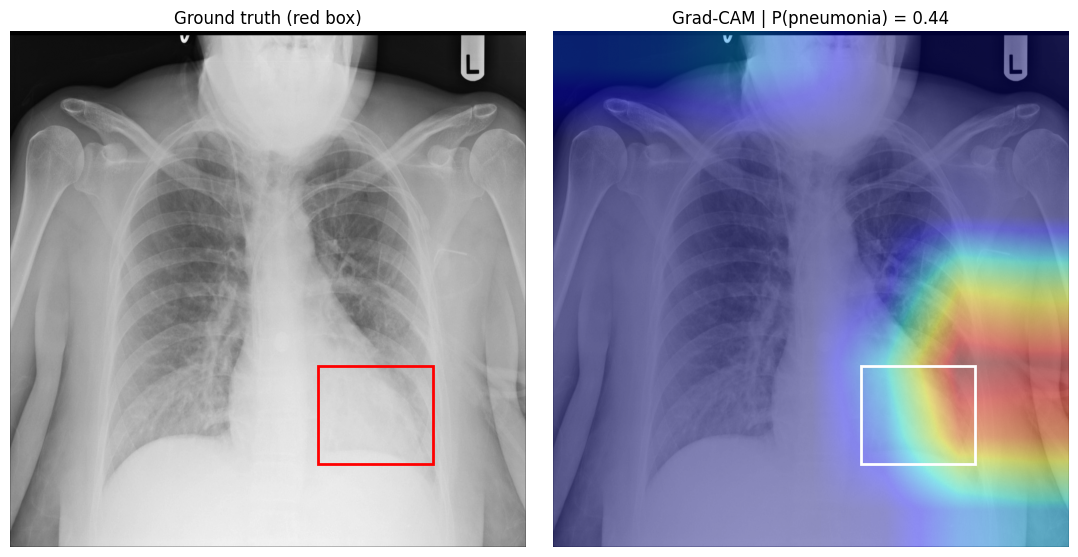

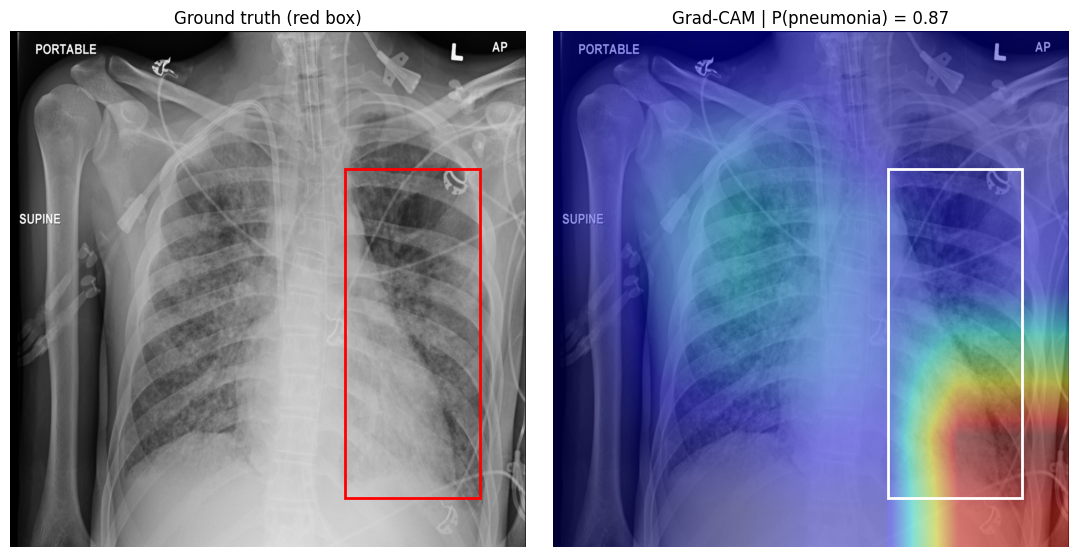

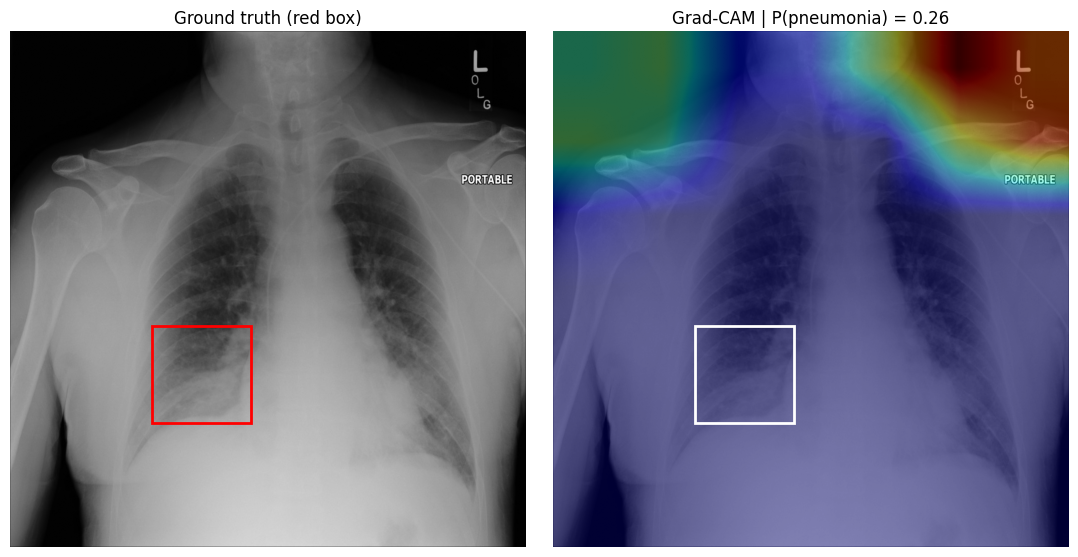

In [88]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches

model.load_state_dict(torch.load("best_densenet121.pth", map_location=device))
model.eval()

def compute_gradcam(model, img_tensor):
    """img_tensor: (3, 224, 224). Returns a 224x224 heatmap in [0, 1] and the pneumonia probability."""
    x = img_tensor.unsqueeze(0).to(device)

    # Manual DenseNet forward so we can grab the last feature maps
    feats = model.features(x)
    feats = F.relu(feats)
    feats.retain_grad()

    pooled = F.adaptive_avg_pool2d(feats, (1, 1)).flatten(1)
    out = model.classifier(pooled)

    model.zero_grad()
    out[0, 0].backward()

    # Importance weight of each feature map = average gradient
    weights = feats.grad.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * feats).sum(dim=1, keepdim=True))

    cam = F.interpolate(cam, size=(224, 224), mode="bilinear", align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    return cam, torch.sigmoid(out).item()


def show_gradcam(row, dataset_index):
    # Original image for display
    dicom = pydicom.dcmread(row["image_path"])
    original = dicom.pixel_array
    H, W = original.shape

    # Model input + heatmap
    img_tensor, _ = test_dataset[dataset_index]
    cam, prob = compute_gradcam(model, img_tensor)

    # Resize heatmap to original image size
    cam_full = F.interpolate(
        torch.tensor(cam)[None, None], size=(H, W),
        mode="bilinear", align_corners=False
    ).squeeze().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

    # Left: ground truth
    axes[0].imshow(original, cmap="gray")
    axes[0].add_patch(patches.Rectangle(
        (row["x"], row["y"]), row["width"], row["height"],
        linewidth=2, edgecolor="red", facecolor="none"))
    axes[0].set_title("Ground truth (red box)")
    axes[0].axis("off")

    # Right: Grad-CAM
    axes[1].imshow(original, cmap="gray")
    axes[1].imshow(cam_full, cmap="jet", alpha=0.4)
    axes[1].add_patch(patches.Rectangle(
        (row["x"], row["y"]), row["width"], row["height"],
        linewidth=2, edgecolor="white", facecolor="none"))
    axes[1].set_title(f"Grad-CAM | P(pneumonia) = {prob:.2f}")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


# Show 5 pneumonia cases from the test set
pos_rows = test_small.reset_index(drop=True)
pos_rows = pos_rows[pos_rows["Target"] == 1].head(5)

for idx, row in pos_rows.iterrows():
    show_gradcam(row, idx)

In [89]:
boxes_df = pd.read_csv(os.path.join(path, "stage_2_train_labels.csv"))

test_reset = test_small.reset_index(drop=True)
pos_cases = test_reset[test_reset["Target"] == 1]
print("Pneumonia cases in test set:", len(pos_cases))

def gt_mask(patient_id, size=224):
    """Binary mask of ALL ground-truth boxes, scaled to 224x224 (RSNA images are 1024x1024)."""
    rows = boxes_df[(boxes_df["patientId"] == patient_id) & (boxes_df["Target"] == 1)]
    mask = np.zeros((size, size), dtype=bool)
    s = size / 1024
    for _, r in rows.iterrows():
        x1, y1 = int(r["x"] * s), int(r["y"] * s)
        x2, y2 = int((r["x"] + r["width"]) * s), int((r["y"] + r["height"]) * s)
        mask[y1:y2, x1:x2] = True
    return mask

def iou(a, b):
    union = np.logical_or(a, b).sum()
    return np.logical_and(a, b).sum() / union if union > 0 else 0.0

# Compute each heatmap once and cache it
cams, gts, probs = [], [], []
for idx, row in pos_cases.iterrows():
    img_tensor, _ = test_dataset[idx]
    cam, prob = compute_gradcam(model, img_tensor)
    cams.append(cam)
    gts.append(gt_mask(row["patientId"]))
    probs.append(prob)

# Try a few thresholds
for thr in [0.3, 0.5, 0.7]:
    ious = [iou(cam >= thr, gt) for cam, gt in zip(cams, gts)]
    print(f"Threshold {thr:.1f} | mean IoU: {np.mean(ious):.3f} | "
          f"median: {np.median(ious):.3f} | IoU>0.1: {np.mean(np.array(ious) > 0.1)*100:.0f}%")

# Pointing game: does the single hottest pixel fall inside a true box?
hits = []
for cam, gt in zip(cams, gts):
    y, x = np.unravel_index(cam.argmax(), cam.shape)
    hits.append(gt[y, x])
print(f"Pointing game hit rate: {np.mean(hits)*100:.1f}%")

# Only the cases the model actually detected (prob >= 0.5)
detected = [i for i, p in enumerate(probs) if p >= 0.5]
ious_det = [iou(cams[i] >= 0.5, gts[i]) for i in detected]
print(f"Detected cases: {len(detected)} | mean IoU (thr 0.5): {np.mean(ious_det):.3f}")

Pneumonia cases in test set: 106
Threshold 0.3 | mean IoU: 0.204 | median: 0.171 | IoU>0.1: 73%
Threshold 0.5 | mean IoU: 0.228 | median: 0.227 | IoU>0.1: 71%
Threshold 0.7 | mean IoU: 0.202 | median: 0.212 | IoU>0.1: 63%
Pointing game hit rate: 34.0%
Detected cases: 87 | mean IoU (thr 0.5): 0.262


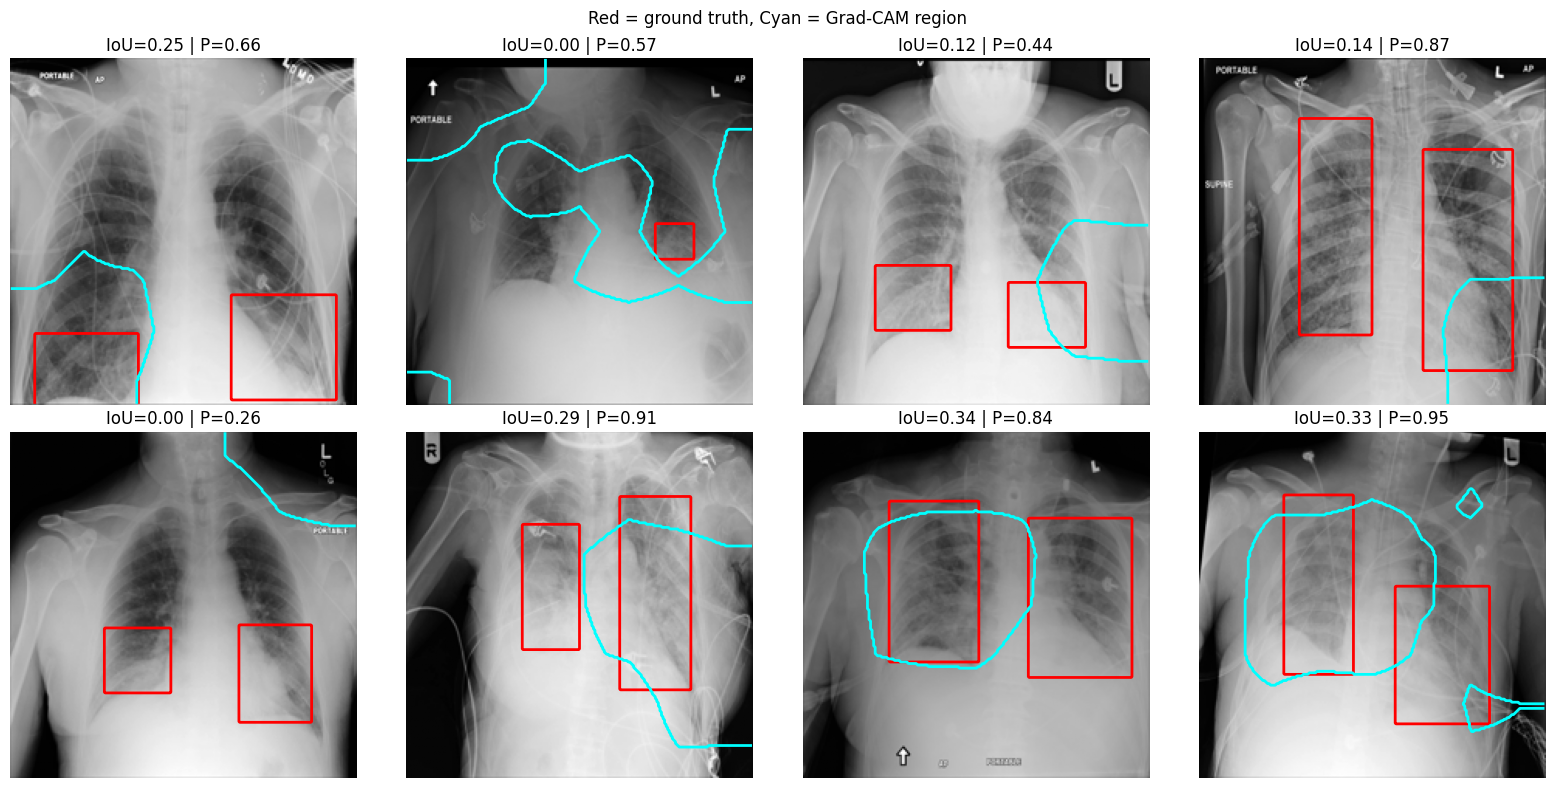

In [90]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for k, ax in enumerate(axes.flat):
    if k >= len(cams): ax.axis("off"); continue
    row = pos_cases.iloc[k]
    img = pydicom.dcmread(row["image_path"]).pixel_array
    img = np.array(Image.fromarray(img).resize((224, 224)))
    pred_mask = cams[k] >= 0.5

    ax.imshow(img, cmap="gray")
    ax.contour(gts[k], levels=[0.5], colors="red", linewidths=2)        # ground truth
    ax.contour(pred_mask, levels=[0.5], colors="cyan", linewidths=2)    # Grad-CAM region
    ax.set_title(f"IoU={iou(pred_mask, gts[k]):.2f} | P={probs[k]:.2f}")
    ax.axis("off")
plt.suptitle("Red = ground truth, Cyan = Grad-CAM region")
plt.tight_layout()
plt.show()

In [91]:

import numpy as np
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        # Model prediction: raw logits
        logits = model(images).reshape(-1)

        # Convert logits to probabilities between 0 and 1
        probabilities = torch.sigmoid(logits)

        all_probs.extend(probabilities.cpu().numpy())
        all_labels.extend(labels.reshape(-1).cpu().numpy())

y_true = np.asarray(all_labels).astype(int)
y_probs = np.asarray(all_probs)
y_pred = (y_probs >= 0.5).astype(int)

print("Test images:", len(y_true))
print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
print("Precision:", round(
    precision_score(y_true, y_pred, zero_division=0), 4
))
print("Recall:", round(
    recall_score(y_true, y_pred, zero_division=0), 4
))
print("F1-score:", round(
    f1_score(y_true, y_pred, zero_division=0), 4
))

if len(np.unique(y_true)) == 2:
    print("ROC-AUC:", round(roc_auc_score(y_true, y_probs), 4))
else:
    print("ROC-AUC unavailable: test set has only one class.")

print("\nConfusion matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["No Pneumonia", "Pneumonia"],
    zero_division=0
))

Test images: 500
Accuracy: 0.724
Precision: 0.4223
Recall: 0.8208
F1-score: 0.5577
ROC-AUC: 0.8519

Confusion matrix:
[[275 119]
 [ 19  87]]

Classification report:
              precision    recall  f1-score   support

No Pneumonia       0.94      0.70      0.80       394
   Pneumonia       0.42      0.82      0.56       106

    accuracy                           0.72       500
   macro avg       0.68      0.76      0.68       500
weighted avg       0.83      0.72      0.75       500



Grad-CAM localization results:
 Threshold  Cases evaluated  Mean IoU
       0.3              106    0.2038
       0.4              106    0.2202
       0.5              106    0.2279
       0.6              106    0.2256
       0.7              106    0.2022


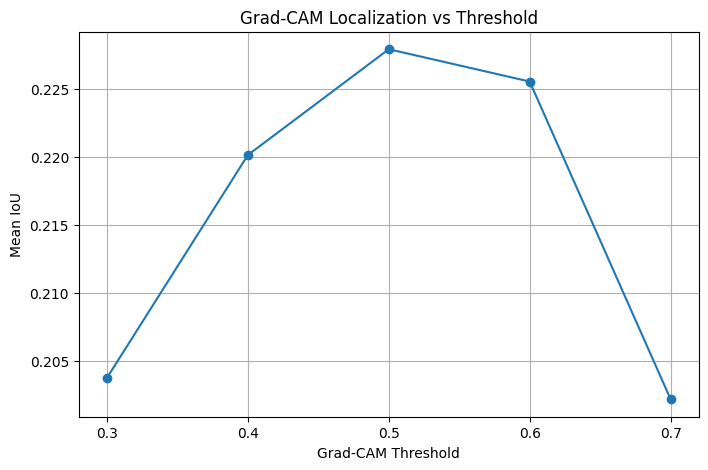

In [92]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def calculate_iou(pred_mask, true_mask):
    pred_mask = np.asarray(pred_mask, dtype=bool)
    true_mask = np.asarray(true_mask, dtype=bool)

    if pred_mask.shape != true_mask.shape:
        raise ValueError(
            f"Mask shapes differ: {pred_mask.shape} vs {true_mask.shape}"
        )

    intersection = np.logical_and(pred_mask, true_mask).sum()
    union = np.logical_or(pred_mask, true_mask).sum()

    return intersection / union if union > 0 else 0.0


# Try several thresholds on the same Grad-CAM maps
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

num_cases = min(len(cams), len(gts), len(pos_cases))

for threshold in thresholds:
    case_ious = []

    for k in range(num_cases):
        cam = np.asarray(cams[k])
        ground_truth = np.asarray(gts[k])

        predicted_mask = cam >= threshold
        score = calculate_iou(predicted_mask, ground_truth)
        case_ious.append(score)

    results.append({
        "Threshold": threshold,
        "Cases evaluated": len(case_ious),
        "Mean IoU": np.mean(case_ious) if case_ious else np.nan
    })

results_df = pd.DataFrame(results)

print("Grad-CAM localization results:")
print(results_df.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(
    results_df["Threshold"],
    results_df["Mean IoU"],
    marker="o"
)
plt.xlabel("Grad-CAM Threshold")
plt.ylabel("Mean IoU")
plt.title("Grad-CAM Localization vs Threshold")
plt.xticks(thresholds)
plt.grid(True)
plt.show()

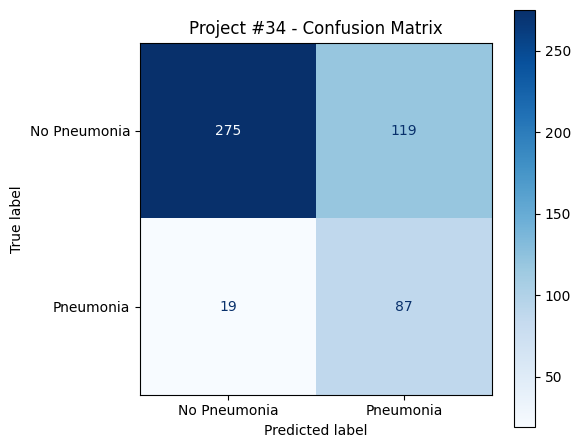

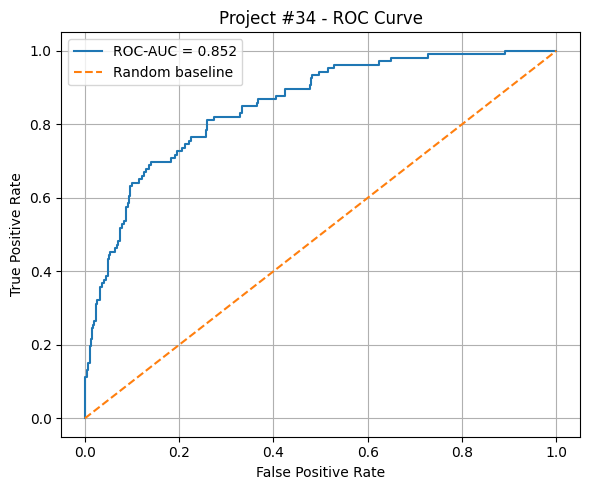

Plots saved in project34_results/


In [93]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

# Create a folder for project results
os.makedirs("project34_results", exist_ok=True)

# 1. Confusion matrix
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Pneumonia", "Pneumonia"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title("Project #34 - Confusion Matrix")
plt.tight_layout()
plt.savefig(
    "project34_results/confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()


# 2. ROC curve (only possible when both classes are present)
if len(np.unique(y_true)) == 2:
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    auc_score = roc_auc_score(y_true, y_probs)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Project #34 - ROC Curve")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(
        "project34_results/roc_curve.png",
        dpi=200,
        bbox_inches="tight"
    )
    plt.show()
else:
    print("ROC curve skipped: both classes are needed.")

print("Plots saved in project34_results/")

In [94]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

metrics = {
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0),
        (
            roc_auc_score(y_true, y_probs)
            if len(np.unique(y_true)) == 2
            else np.nan
        )
    ]
}

metrics_df = pd.DataFrame(metrics)
print(metrics_df.round(4).to_string(index=False))

metrics_df.to_csv(
    "project34_results/classification_metrics.csv",
    index=False
)

print("\nMetrics saved successfully.")

   Metric  Value
 Accuracy 0.7240
Precision 0.4223
   Recall 0.8208
 F1-score 0.5577
  ROC-AUC 0.8519

Metrics saved successfully.


Localization summary:
 Threshold  Cases_Evaluated  Mean_IoU  Std_IoU
       0.3              106    0.2038   0.1498
       0.4              106    0.2202   0.1633
       0.5              106    0.2279   0.1714
       0.6              106    0.2256   0.1724
       0.7              106    0.2022   0.1708


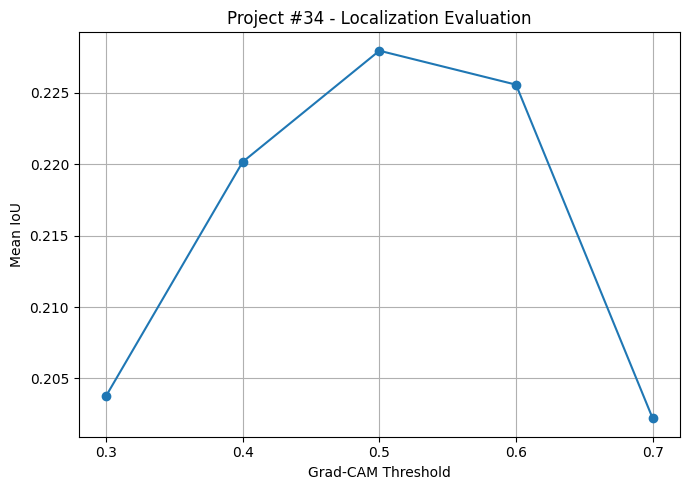


Cases evaluated: 106
Localization CSV files and plot saved in project34_results/


In [95]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("project34_results", exist_ok=True)

def calculate_iou(pred_mask, true_mask):
    pred_mask = np.asarray(pred_mask, dtype=bool)
    true_mask = np.asarray(true_mask, dtype=bool)

    if pred_mask.shape != true_mask.shape:
        raise ValueError(
            f"Mask shapes differ: {pred_mask.shape} and {true_mask.shape}"
        )

    intersection = np.logical_and(pred_mask, true_mask).sum()
    union = np.logical_or(pred_mask, true_mask).sum()

    # If both masks are empty, define IoU as 0 for this evaluation.
    return intersection / union if union > 0 else 0.0


thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
num_cases = min(len(cams), len(gts), len(pos_cases))

if num_cases == 0:
    raise ValueError("No localization cases found. Check cams, gts and pos_cases.")

rows = []

for k in range(num_cases):
    for threshold in thresholds:
        pred_mask = np.asarray(cams[k]) >= threshold
        true_mask = np.asarray(gts[k]) >= 0.5

        rows.append({
            "Case": k + 1,
            "Threshold": threshold,
            "IoU": calculate_iou(pred_mask, true_mask)
        })

localization_df = pd.DataFrame(rows)

# Average IoU across the evaluated cases for each threshold
summary_df = (
    localization_df
    .groupby("Threshold", as_index=False)
    .agg(
        Cases_Evaluated=("Case", "nunique"),
        Mean_IoU=("IoU", "mean"),
        Std_IoU=("IoU", "std")
    )
)

print("Localization summary:")
print(summary_df.round(4).to_string(index=False))

localization_df.to_csv(
    "project34_results/localization_per_case.csv",
    index=False
)

summary_df.to_csv(
    "project34_results/localization_summary.csv",
    index=False
)

# Plot mean IoU against threshold
plt.figure(figsize=(7, 5))
plt.plot(
    summary_df["Threshold"],
    summary_df["Mean_IoU"],
    marker="o"
)
plt.xlabel("Grad-CAM Threshold")
plt.ylabel("Mean IoU")
plt.title("Project #34 - Localization Evaluation")
plt.xticks(thresholds)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "project34_results/localization_iou.png",
    dpi=200,
    bbox_inches="tight"
)
plt.show()

print(f"\nCases evaluated: {num_cases}")
print("Localization CSV files and plot saved in project34_results/")

In [96]:

import os

print("Current working directory:", os.getcwd())
print("\nFiles and folders here:")

for item in sorted(os.listdir(".")):
    print(item)

Current working directory: /content

Files and folders here:
.config
best_densenet121.pth
best_densenet121_v2.pth
drive
project34_results
sample_data


In [97]:

import os

print("MODEL CHECKPOINT")
model_path = "/content/best_densenet121.pth"
print("Exists:", os.path.isfile(model_path))

if os.path.isfile(model_path):
    print("Size (MB):", round(os.path.getsize(model_path) / (1024**2), 2))

print("\nRESULTS FOLDER")
results_path = "/content/project34_results"

if os.path.isdir(results_path):
    for name in sorted(os.listdir(results_path)):
        full_path = os.path.join(results_path, name)
        if os.path.isfile(full_path):
            size_kb = os.path.getsize(full_path) / 1024
            print(f"{name} — {size_kb:.1f} KB")
        else:
            print(f"{name}/")
else:
    print("Results folder not found.")

MODEL CHECKPOINT
Exists: True
Size (MB): 27.11

RESULTS FOLDER
classification_metrics.csv — 0.1 KB
confusion_matrix.png — 50.6 KB
localization_iou.png — 73.9 KB
localization_per_case.csv — 12.7 KB
localization_summary.csv — 0.3 KB
roc_curve.png — 70.3 KB


In [98]:

from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

# Change this path if your project is inside another folder in MyDrive
PROJECT_DIR = "/content/drive/MyDrive/Pneumonia-Detection-Localization"

MODEL_SOURCE = "/content/best_densenet121.pth"
RESULTS_SOURCE = "/content/project34_results"

MODEL_DEST = os.path.join(PROJECT_DIR, "models", "best_densenet121.pth")
RESULTS_DEST = os.path.join(PROJECT_DIR, "results", "project34_results")

# Check that the project folder exists
if not os.path.isdir(PROJECT_DIR):
    print("Project folder not found. Check the PROJECT_DIR path.")
else:
    # Copy model only if it won't overwrite an existing file
    if os.path.exists(MODEL_SOURCE):
        if os.path.exists(MODEL_DEST):
            print("Model already exists in Drive; skipped to avoid overwriting.")
        else:
            shutil.copy2(MODEL_SOURCE, MODEL_DEST)
            print("Model copied successfully.")
    else:
        print("Model not found in the current Colab runtime.")

    # Copy results only if the destination does not already exist
    if os.path.isdir(RESULTS_SOURCE):
        if os.path.exists(RESULTS_DEST):
            print("Results folder already exists in Drive; skipped to avoid overwriting.")
        else:
            shutil.copytree(RESULTS_SOURCE, RESULTS_DEST)
            print("Results copied successfully.")
    else:
        print("Results folder not found in the current Colab runtime.")

print("Finished checking model and results.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model already exists in Drive; skipped to avoid overwriting.
Results folder already exists in Drive; skipped to avoid overwriting.
Finished checking model and results.


In [99]:

import os

print("Folders in MyDrive:")
for name in os.listdir("/content/drive/MyDrive"):
    path = os.path.join("/content/drive/MyDrive", name)
    if os.path.isdir(path):
        print("📁", name)

Folders in MyDrive:
📁 Colab Notebooks
📁 Google Earth
📁 clideo.com
📁 Classroom
📁 Pneumonia-Detection-Localization


In [100]:
import os

project_dir = "/content/drive/MyDrive/Pneumonia-Detection-Localization"

print("Project found:", os.path.isdir(project_dir))

if os.path.isdir(project_dir):
    print("Folders:", os.listdir(project_dir))

Project found: True
Folders: ['.DS_Store', 'app', 'models', 'data', 'results', 'notebooks', 'src']


In [101]:
import os

project_dir = "/content/drive/MyDrive/Pneumonia-Detection-Localization"

for root, dirs, files in os.walk(project_dir):
    level = root.replace(project_dir, "").count(os.sep)
    print("  " * level + os.path.basename(root) + "/")
    for file in files:
        print("  " * (level + 1) + file)

Pneumonia-Detection-Localization/
  .DS_Store
  app/
  models/
    best_densenet121.pth
    best_densenet121_v2.pth
  data/
  results/
    project34_results/
      localization_per_case.csv
      localization_iou.png
      localization_summary.csv
      classification_metrics.csv
      confusion_matrix.png
      roc_curve.png
  notebooks/
  src/


In [102]:

import os
import shutil

PROJECT_DIR = "/content/drive/MyDrive/Pneumonia-Detection-Localization"

# 1. Copy the trained model
model_src = "/content/best_densenet121.pth"
model_dst = os.path.join(PROJECT_DIR, "models", "best_densenet121.pth")

if os.path.isfile(model_src):
    if os.path.exists(model_dst):
        print("Model already exists in Drive — skipped.")
    else:
        shutil.copy2(model_src, model_dst)
        print("Model copied to models/ successfully.")
else:
    print("Model not found in the current Colab runtime.")

# 2. Copy evaluation results
results_src = "/content/project34_results"
results_dst = os.path.join(PROJECT_DIR, "results", "project34_results")

if os.path.isdir(results_src):
    if os.path.exists(results_dst):
        print("Results already exist in Drive — skipped.")
    else:
        shutil.copytree(results_src, results_dst)
        print("Evaluation results copied successfully.")
else:
    print("Evaluation results folder not found in the current runtime.")

# 3. Verify the saved files
print("\nMODEL EXISTS:", os.path.isfile(model_dst))
print("RESULTS FOLDER EXISTS:", os.path.isdir(results_dst))

if os.path.isdir(results_dst):
    print("Result files:", os.listdir(results_dst))

Model already exists in Drive — skipped.
Results already exist in Drive — skipped.

MODEL EXISTS: True
RESULTS FOLDER EXISTS: True
Result files: ['localization_per_case.csv', 'localization_iou.png', 'localization_summary.csv', 'classification_metrics.csv', 'confusion_matrix.png', 'roc_curve.png']


In [103]:

import os
import pandas as pd

RESULTS_DIR = (
    "/content/drive/MyDrive/"
    "Pneumonia-Detection-Localization/results/project34_results"
)

for filename in [
    "classification_metrics.csv",
    "localization_summary.csv"
]:
    filepath = os.path.join(RESULTS_DIR, filename)

    print("\n" + "=" * 45)
    print(filename)
    print("=" * 45)

    if os.path.isfile(filepath):
        display(pd.read_csv(filepath))
    else:
        print("File not found:", filepath)


classification_metrics.csv


,Metric,Value
0,Accuracy,0.772000
1,Precision,0.477273
2,Recall,0.792453
3,F1-score,0.595745
4,ROC-AUC,0.852289



localization_summary.csv


,Threshold,Cases_Evaluated,Mean_IoU,Std_IoU
0,0.3,106,0.213367,0.151101
1,0.4,106,0.222051,0.148658
2,0.5,106,0.218030,0.141716
3,0.6,106,0.202586,0.138988
4,0.7,106,0.175766,0.139788


In [104]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_set(model, loader, device):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images).reshape(-1)
            probabilities = torch.sigmoid(logits)

            all_probs.extend(probabilities.cpu().numpy())
            all_labels.extend(labels.reshape(-1).cpu().numpy())

    y_true = np.asarray(all_labels).astype(int)
    y_probs = np.asarray(all_probs)
    y_pred = (y_probs >= 0.5).astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_probs) if len(np.unique(y_true)) == 2 else np.nan

    return accuracy, precision, recall, f1, auc

print("\n--- Evaluating Training Set ---")
train_acc, train_prec, train_rec, train_f1, train_auc = evaluate_set(model, train_loader, device)
print(f"Accuracy: {train_acc:.4f}")
print(f"Precision: {train_prec:.4f}")
print(f"Recall: {train_rec:.4f}")
print(f"F1-score: {train_f1:.4f}")
print(f"ROC-AUC: {train_auc:.4f}")

print("\n--- Evaluating Validation Set ---")
val_acc, val_prec, val_rec, val_f1, val_auc = evaluate_set(model, val_loader, device)
print(f"Accuracy: {val_acc:.4f}")
print(f"Precision: {val_prec:.4f}")
print(f"Recall: {val_rec:.4f}")
print(f"F1-score: {val_f1:.4f}")
print(f"ROC-AUC: {val_auc:.4f}")

print("\n--- Evaluating Test Set ---")
test_acc, test_prec, test_rec, test_f1, test_auc = evaluate_set(model, test_loader, device)
print(f"Accuracy: {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall: {test_rec:.4f}")
print(f"F1-score: {test_f1:.4f}")
print(f"ROC-AUC: {test_auc:.4f}")


--- Evaluating Training Set ---
Accuracy: 0.8380
Precision: 0.5849
Recall: 0.9644
F1-score: 0.7282
ROC-AUC: 0.9651

--- Evaluating Validation Set ---
Accuracy: 0.7900
Precision: 0.5424
Recall: 0.8000
F1-score: 0.6465
ROC-AUC: 0.8447

--- Evaluating Test Set ---
Accuracy: 0.7240
Precision: 0.4223
Recall: 0.8208
F1-score: 0.5577
ROC-AUC: 0.8519


In [105]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
import os, time, shutil
from sklearn.metrics import roc_auc_score

torch.manual_seed(42)

# Augmentation for training only
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Validation/test keep the plain transform from before
# Full training set, full validation set. test_small stays the same,
# so the old and new models are compared on identical test images.
train_dataset_v2 = PneumoniaDataset(train_data, transform=train_transform)
val_dataset_v2   = PneumoniaDataset(val_data,   transform=transform)

train_loader_v2 = DataLoader(train_dataset_v2, batch_size=32, shuffle=True,  num_workers=4)
val_loader_v2   = DataLoader(val_dataset_v2,   batch_size=32, shuffle=False, num_workers=4)

print("Train:", len(train_dataset_v2), "| Val:", len(val_dataset_v2))

Train: 18678 | Val: 4003


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [106]:
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
model.classifier = nn.Linear(model.classifier.in_features, 1)
model = model.to(device)

num_neg = (train_data["Target"] == 0).sum()
num_pos = (train_data["Target"] == 1).sum()
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)
print("pos_weight:", pos_weight.item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=1
)

pos_weight: 3.438688278198242


In [107]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/Pneumonia-Detection-Localization/models"
os.makedirs(SAVE_DIR, exist_ok=True)
BEST_PATH = "best_densenet121_v2.pth"

MAX_EPOCHS = 10
PATIENCE = 3          # stop if no improvement for 3 epochs
best_auc, bad_epochs = 0, 0

for epoch in range(MAX_EPOCHS):
    start = time.time()
    train_loss = train_one_epoch(model, train_loader_v2)
    val_loss, val_auc = evaluate(model, val_loader_v2)
    scheduler.step(val_auc)

    print(f"Epoch {epoch+1}/{MAX_EPOCHS} | Train loss: {train_loss:.4f} | "
          f"Val loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.1e} | {time.time()-start:.0f}s")

    if val_auc > best_auc:
        best_auc, bad_epochs = val_auc, 0
        torch.save(model.state_dict(), BEST_PATH)
        shutil.copy(BEST_PATH, os.path.join(SAVE_DIR, BEST_PATH))   # backup to Drive
        print("  -> saved best model (also copied to Drive)")
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print("Early stopping.")
            break

print("Best validation AUC:", round(best_auc, 4))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/10 | Train loss: 0.7617 | Val loss: 0.7001 | Val AUC: 0.8708 | LR: 3.0e-05 | 439s
  -> saved best model (also copied to Drive)


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 2/10 | Train loss: 0.6907 | Val loss: 0.6951 | Val AUC: 0.8725 | LR: 3.0e-05 | 438s
  -> saved best model (also copied to Drive)


...

Epoch 4/10 | Train loss: 0.6292 | Val loss: 0.6963 | Val AUC: 0.8745 | LR: 3.0e-05 | 451s


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 5/10 | Train loss: 0.5995 | Val loss: 0.7007 | Val AUC: 0.8782 | LR: 1.5e-05 | 439s


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 6/10 | Train loss: 0.5483 | Val loss: 0.6962 | Val AUC: 0.8803 | LR: 1.5e-05 | 434s
Early stopping.
Best validation AUC: 0.8806


In [108]:
import numpy as np, pandas as pd, os
from sklearn.metrics import (roc_auc_score, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

model.load_state_dict(torch.load("best_densenet121_v2.pth", map_location=device))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in test_loader:
        out = model(imgs.to(device))
        all_probs.extend(torch.sigmoid(out).cpu().numpy().flatten())
        all_labels.extend(lbls.numpy().flatten())
all_probs, all_labels = np.array(all_probs), np.array(all_labels)

preds = (all_probs >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()

metrics_v2 = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Specificity"],
    "Value": [accuracy_score(all_labels, preds), precision_score(all_labels, preds),
              recall_score(all_labels, preds), f1_score(all_labels, preds),
              roc_auc_score(all_labels, all_probs), tn / (tn + fp)],
})
print(metrics_v2)
print(f"TN={tn} FP={fp} FN={fn} TP={tp}")

        Metric     Value
0     Accuracy  0.808000
1    Precision  0.531250
2       Recall  0.801887
3     F1-score  0.639098
4      ROC-AUC  0.883560
5  Specificity  0.809645
TN=319 FP=75 FN=21 TP=85


In [109]:
test_reset = test_small.reset_index(drop=True)
pos_cases = test_reset[test_reset["Target"] == 1]

cams, gts, probs = [], [], []
for idx, row in pos_cases.iterrows():
    img_tensor, _ = test_dataset[idx]
    cam, prob = compute_gradcam(model, img_tensor)
    cams.append(cam); gts.append(gt_mask(row["patientId"])); probs.append(prob)

rows = []
for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    ious = [iou(c >= thr, g) for c, g in zip(cams, gts)]
    rows.append({"Threshold": thr, "Cases_Evaluated": len(ious),
                 "Mean_IoU": np.mean(ious), "Std_IoU": np.std(ious)})
loc_v2 = pd.DataFrame(rows)
print(loc_v2)

hits = [g[np.unravel_index(c.argmax(), c.shape)] for c, g in zip(cams, gts)]
print(f"Pointing game hit rate: {np.mean(hits)*100:.1f}%")

   Threshold  Cases_Evaluated  Mean_IoU   Std_IoU
0        0.3              106  0.260569  0.182173
1        0.4              106  0.274445  0.183728
2        0.5              106  0.279109  0.177670
3        0.6              106  0.267101  0.168423
4        0.7              106  0.247253  0.169978
Pointing game hit rate: 47.2%


In [110]:
out_dir = "/content/drive/MyDrive/Pneumonia-Detection-Localization/results/project34_results_v2"
os.makedirs(out_dir, exist_ok=True)
metrics_v2.to_csv(f"{out_dir}/classification_metrics.csv", index=False)
loc_v2.to_csv(f"{out_dir}/localization_summary.csv", index=False)
print("Saved to:", out_dir)

Saved to: /content/drive/MyDrive/Pneumonia-Detection-Localization/results/project34_results_v2


In [112]:
import os, numpy as np, pydicom
from PIL import Image

demo_dir = "/content/drive/MyDrive/Pneumonia-Detection-Localization/demo_samples"
os.makedirs(demo_dir, exist_ok=True)

tr = test_small.reset_index(drop=True)
groups = [("pneumonia", tr[tr["Target"] == 1].head(3)),
          ("normal",    tr[tr["Target"] == 0].head(3))]

for name, df in groups:
    for i, (_, r) in enumerate(df.iterrows()):
        arr = pydicom.dcmread(r["image_path"]).pixel_array.astype(np.float32)
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
        Image.fromarray((arr * 255).astype(np.uint8)).save(f"{demo_dir}/{name}_{i+1}.png")

print(sorted(os.listdir(demo_dir)))

['normal_1.png', 'normal_2.png', 'normal_3.png', 'pneumonia_1.png', 'pneumonia_2.png', 'pneumonia_3.png']


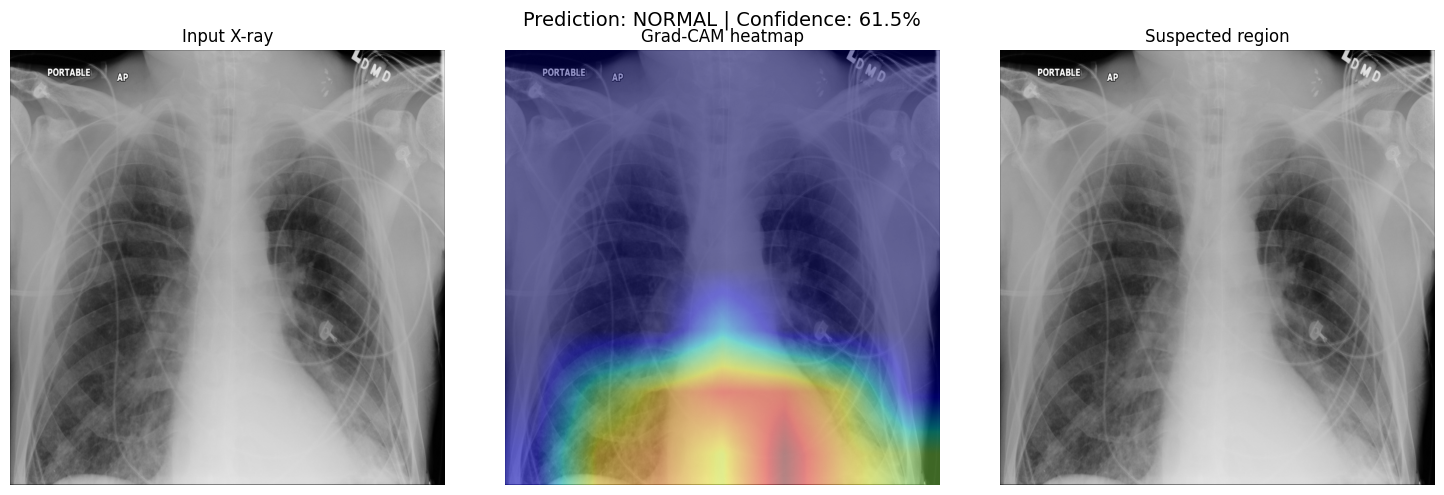

In [113]:
import numpy as np, matplotlib.pyplot as plt, matplotlib.patches as patches
import torch.nn.functional as F
from PIL import Image

model.load_state_dict(torch.load("best_densenet121_v2.pth", map_location=device))
model.eval()

fname = "/content/drive/MyDrive/Pneumonia-Detection-Localization/demo_samples/pneumonia_1.png"

raw = np.array(Image.open(fname).convert("L"))
H, W = raw.shape
img = Image.fromarray(raw).convert("RGB")
tensor = transform(img)

cam, prob = compute_gradcam(model, tensor)
label = "PNEUMONIA" if prob >= 0.5 else "NORMAL"
conf = prob if prob >= 0.5 else 1 - prob

cam_full = F.interpolate(torch.tensor(cam)[None, None], size=(H, W),
                         mode="bilinear", align_corners=False).squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(raw, cmap="gray"); axes[0].set_title("Input X-ray"); axes[0].axis("off")
axes[1].imshow(raw, cmap="gray"); axes[1].imshow(cam_full, cmap="jet", alpha=0.4)
axes[1].set_title("Grad-CAM heatmap"); axes[1].axis("off")
axes[2].imshow(raw, cmap="gray")
if prob >= 0.5:
    ys, xs = np.where(cam_full >= 0.5)
    if len(xs):
        axes[2].add_patch(patches.Rectangle((xs.min(), ys.min()),
            xs.max() - xs.min(), ys.max() - ys.min(),
            linewidth=2, edgecolor="cyan", facecolor="none"))
axes[2].set_title("Suspected region"); axes[2].axis("off")
plt.suptitle(f"Prediction: {label} | Confidence: {conf*100:.1f}%", fontsize=14)
plt.tight_layout()
plt.savefig("/content/demo_output.png", dpi=150, bbox_inches="tight")
plt.show()

pneumonia_1    true=PNEUMONIA  pred=NORMAL     P(pneumonia)=0.385  WRONG
pneumonia_2    true=PNEUMONIA  pred=PNEUMONIA  P(pneumonia)=0.695  correct
pneumonia_3    true=PNEUMONIA  pred=NORMAL     P(pneumonia)=0.308  WRONG
normal_1       true=NORMAL     pred=NORMAL     P(pneumonia)=0.392  correct
normal_2       true=NORMAL     pred=NORMAL     P(pneumonia)=0.459  correct
normal_3       true=NORMAL     pred=NORMAL     P(pneumonia)=0.077  correct


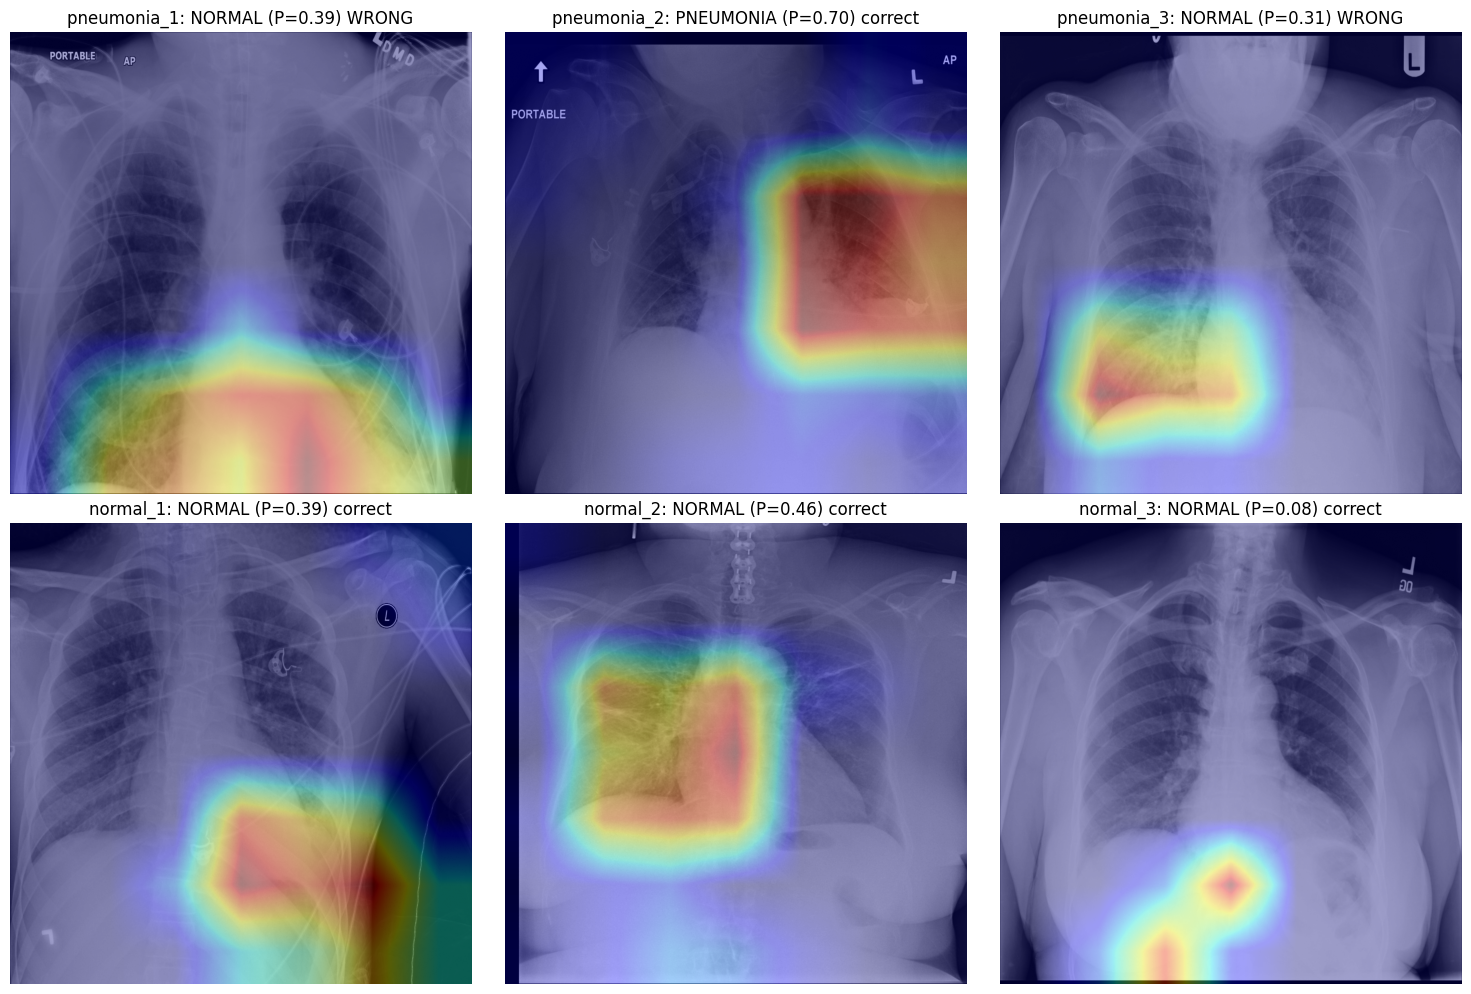

In [114]:
import numpy as np, matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image

demo_dir = "/content/drive/MyDrive/Pneumonia-Detection-Localization/demo_samples"
names = ["pneumonia_1", "pneumonia_2", "pneumonia_3", "normal_1", "normal_2", "normal_3"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, n in zip(axes.flat, names):
    raw = np.array(Image.open(f"{demo_dir}/{n}.png").convert("L"))
    H, W = raw.shape
    cam, prob = compute_gradcam(model, transform(Image.fromarray(raw).convert("RGB")))
    cam_full = F.interpolate(torch.tensor(cam)[None, None], size=(H, W),
                             mode="bilinear", align_corners=False).squeeze().numpy()
    pred = "PNEUMONIA" if prob >= 0.5 else "NORMAL"
    truth = n.split("_")[0].upper()
    ok = "correct" if pred == truth else "WRONG"
    ax.imshow(raw, cmap="gray"); ax.imshow(cam_full, cmap="jet", alpha=0.35)
    ax.set_title(f"{n}: {pred} (P={prob:.2f}) {ok}")
    ax.axis("off")
    print(f"{n:14s} true={truth:10s} pred={pred:10s} P(pneumonia)={prob:.3f}  {ok}")
plt.tight_layout(); plt.show()

In [115]:
import os
from PIL import Image
import pydicom

demo_dir = "/content/drive/MyDrive/Pneumonia-Detection-Localization/demo_samples"
os.makedirs(demo_dir, exist_ok=True)

def save_png(path, out):
    arr = pydicom.dcmread(path).pixel_array.astype(np.float32)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    Image.fromarray((arr * 255).astype(np.uint8)).save(out)

# Pneumonia cases the model detected (P>=0.5), ranked by localization overlap
rows = pos_cases.reset_index(drop=True)
scores = [(iou(c >= 0.5, g), i) for i, (c, g, p) in enumerate(zip(cams, gts, probs)) if p >= 0.5]
scores.sort(reverse=True)
for k, (s, i) in enumerate(scores[:3]):
    save_png(rows.loc[i, "image_path"], f"{demo_dir}/good_pneumonia_{k+1}_iou{s:.2f}.png")

# Missed pneumonia (honest failure example for the viva)
missed = [i for i, p in enumerate(probs) if p < 0.5]
save_png(rows.loc[missed[0], "image_path"], f"{demo_dir}/missed_pneumonia_1.png")

# Normals the model clears confidently
tr = test_small.reset_index(drop=True)
normals = tr[tr["Target"] == 0].head(40)
res = []
for _, r in normals.iterrows():
    idx = tr.index[tr["patientId"] == r["patientId"]][0]
    _, p = compute_gradcam(model, test_dataset[idx][0])
    res.append((p, r["image_path"]))
res.sort()
for k, (p, path) in enumerate(res[:3]):
    save_png(path, f"{demo_dir}/good_normal_{k+1}_p{p:.2f}.png")

print(sorted(os.listdir(demo_dir)))


['good_normal_1_p0.01.png', 'good_normal_2_p0.01.png', 'good_normal_3_p0.02.png', 'good_pneumonia_1_iou0.61.png', 'good_pneumonia_2_iou0.60.png', 'good_pneumonia_3_iou0.59.png', 'missed_pneumonia_1.png', 'normal_1.png', 'normal_2.png', 'normal_3.png', 'pneumonia_1.png', 'pneumonia_2.png', 'pneumonia_3.png']


good_normal_1_p0.01              -> NORMAL     P(pneumonia)=0.011
good_normal_2_p0.01              -> NORMAL     P(pneumonia)=0.014
good_normal_3_p0.02              -> NORMAL     P(pneumonia)=0.021
good_pneumonia_1_iou0.61         -> PNEUMONIA  P(pneumonia)=0.826
good_pneumonia_2_iou0.60         -> PNEUMONIA  P(pneumonia)=0.907
good_pneumonia_3_iou0.59         -> PNEUMONIA  P(pneumonia)=0.809
missed_pneumonia_1               -> NORMAL     P(pneumonia)=0.385


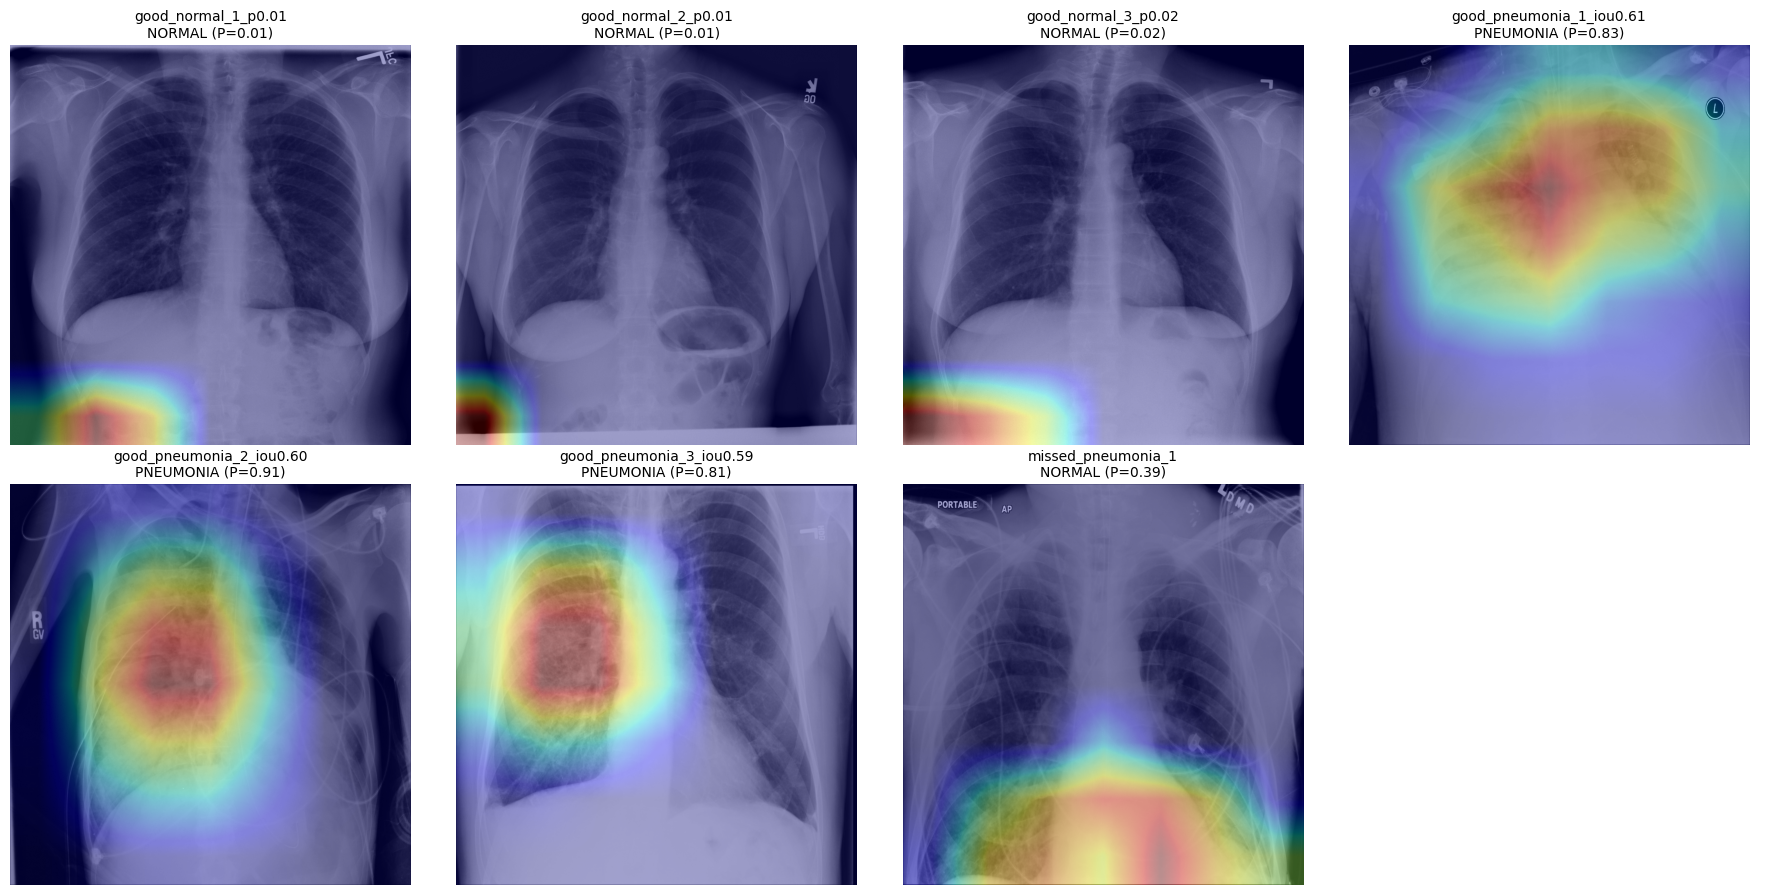

Saved: /content/drive/MyDrive/Pneumonia-Detection-Localization/results/project34_results_v2/demo_gallery.png


In [116]:
import glob, os, numpy as np, matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image

model.load_state_dict(torch.load("best_densenet121_v2.pth", map_location=device))
model.eval()

demo_dir = "/content/drive/MyDrive/Pneumonia-Detection-Localization/demo_samples"
files = sorted(glob.glob(f"{demo_dir}/good_*.png")) + [f"{demo_dir}/missed_pneumonia_1.png"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax in axes.flat:
    ax.axis("off")

for ax, f in zip(axes.flat, files):
    raw = np.array(Image.open(f).convert("L"))
    H, W = raw.shape
    cam, prob = compute_gradcam(model, transform(Image.fromarray(raw).convert("RGB")))
    cam_full = F.interpolate(torch.tensor(cam)[None, None], size=(H, W),
                             mode="bilinear", align_corners=False).squeeze().numpy()
    pred = "PNEUMONIA" if prob >= 0.5 else "NORMAL"
    name = os.path.basename(f).replace(".png", "")
    ax.imshow(raw, cmap="gray"); ax.imshow(cam_full, cmap="jet", alpha=0.35)
    ax.set_title(f"{name}\n{pred} (P={prob:.2f})", fontsize=10)
    print(f"{name:32s} -> {pred:10s} P(pneumonia)={prob:.3f}")

plt.tight_layout()
out = "/content/drive/MyDrive/Pneumonia-Detection-Localization/results/project34_results_v2/demo_gallery.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", out)